# TS1 - Síntesis y operaciones de señales
## Cano Aylin

#### EJERCICIO 1


En este trabajo se sintetizan seis señales distintas, todas generadas con N = 1000 muestras y una frecuencia de muestreo fs = 20000 Hz, elegida para asegurar al menos 10 muestras por período en la señal de 2 kHz. Para cada señal se grafica su forma en el dominio del tiempo junto con el módulo de su espectro, calculado mediante la FFT. Se trabaja con dos señales senoidales, dos tipos de ruido, un pulso rectangular con ciclo de actividad del 50%, y como bonus una delta de Kronecker.

In [3]:
#importacion de modulos
import numpy as np
import matplotlib.pyplot as plt 
import scipy.signal as sig


N=1000 #cantidad de muestras establecidad en la consigna
# ff= 2000 Hz.
# T = 1/2000 = 0.0005 s.
# Ts = T/10 = 0.00005 s
fs= 20000 #frecuencia de muestreo 1/Ts
ts= 1/fs #tiempo entre muestras

#pasamos de muestras a tiempo
tt = np.arange(0, N) * ts

### Inciso 1 - Señal senoidal de 2 kHz

Para elegir la frecuencia de muestreo, primero calculo el período de la señal: T = 1/ff = 1/2000 = 0,0005 s. Necesito al menos 10 muestras por período, entonces el tiempo entre muestras debe ser Ts = T/10 = 0,00005 s. De ahí, la frecuencia de muestreo queda fs = 1/Ts = 20000 Hz.

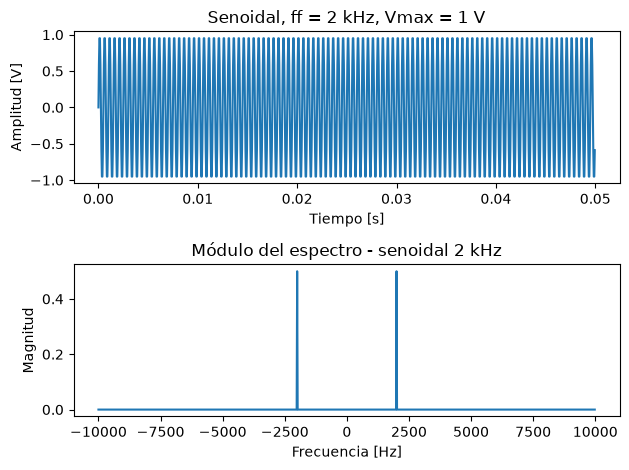

In [4]:
vmax = 1   # amplitud
dc = 0     # desplazamiento vertical
ph = 0     # fase
ff = 2000

#ecuacion de la senal
xx = dc + vmax*np.sin(2*np.pi*ff*tt + ph)

#fft
XX = np.fft.fft(xx)
#calculo su modulo
XX_modulo = np.abs(XX)/N
XX_modulo = np.fft.fftshift(XX_modulo)
#vector de frecuencias
ff_vec = np.fft.fftfreq(N,ts ) 
ff_vec = np.fft.fftshift(ff_vec)

#graficos
plt.figure()
#funcion
plt.subplot(2,1,1)
plt.plot(tt, xx)
plt.title("Senoidal, ff = 2 kHz, Vmax = 1 V")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
#modulo
plt.subplot(2,1,2)
plt.plot(ff_vec, XX_modulo)
plt.title("Módulo del espectro - senoidal 2 kHz")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()

El espectro muestra dos picos simétricos en +2000 Hz y -2000 Hz. Esto se debe a que la señal xx es real, y la transformada de Fourier de una señal real es simétrica en módulo respecto al eje de frecuencia cero. La componente en frecuencia negativa no aporta información adicional,toda la energía de la señal está representada una sola vez, reflejada en ambos lados.

### Inciso 2 - Señal senoidal con potencia media 2 W y desfasaje π/2

La potencia media de una señal senoidal está dada por P = vmax²/2. Esto se debe a que la potencia instantánea es proporcional al cuadrado de la amplitud, y el promedio de sin²(x) a lo largo de un período completo es 1/2. Como se pide P = 2 W, despejo vmax = 2.

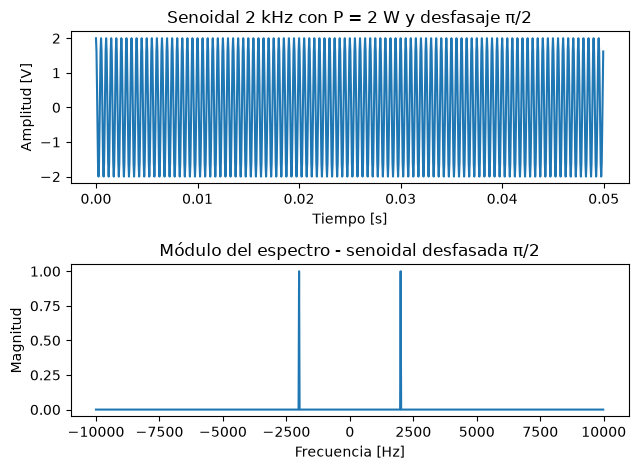

In [6]:
vmax = 2
ph = np.pi/2
xx = dc + vmax*np.sin(2*np.pi*ff*tt + ph)

XX = np.fft.fft(xx)
XX_modulo = np.abs(XX) / N
XX_modulo = np.fft.fftshift(XX_modulo)

plt.figure()

plt.subplot(2,1,1)
plt.plot(tt, xx)
plt.title("Senoidal 2 kHz con P = 2 W y desfasaje π/2")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.subplot(2,1,2)
plt.plot(ff_vec, XX_modulo)
plt.title("Módulo del espectro - senoidal desfasada π/2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()

El espectro conserva los picos en +2000 Hz y -2000Hz, ya que la frecuencia de la señal no cambió. Lo que sí cambia es la magnitud, que pasó de 0.5 a 1, el doble, correspondiente a haber duplicado Vmax. El desfasaje de π/2 agregado no se refleja ya que no modifica el módulo del espectro.

### Inciso 3 - Ruido con distribución normal

Genero el ruido con np.random.normal(dc, sigma, N). Esta función pide como segundo parámetro el desvío estándar, no la varianza directamente. Como conozco la varianza (0.1 W), calculo sigma = √varianza antes de llamar a la función.

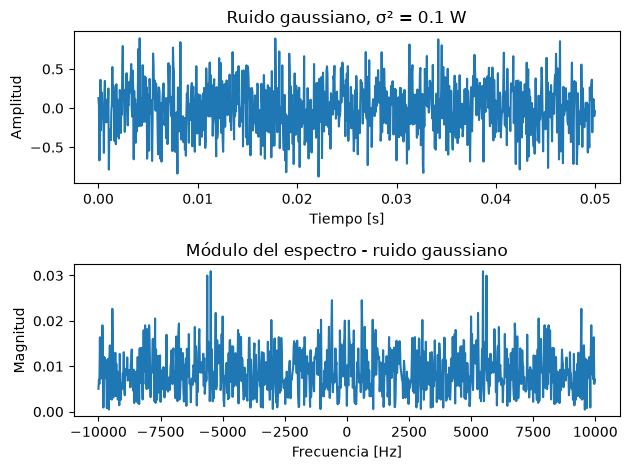

In [7]:
dc= 0 #valor medio
varianza=0.1
sigma= np.sqrt(varianza)

#genero muestras aleatorias con distribucion normal
ruido_normal = np.random.normal(dc, sigma, N)

RN = np.fft.fft(ruido_normal)
RN_modulo = np.abs(RN) / N
RN_modulo = np.fft.fftshift(RN_modulo)

plt.figure()

plt.subplot(2,1,1)
plt.plot(tt, ruido_normal)
plt.title("Ruido gaussiano, σ² = 0.1 W")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(ff_vec, RN_modulo)
plt.title("Módulo del espectro - ruido gaussiano")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()

A diferencia de las señales senoidales, donde toda la energía se concentra en dos frecuencias puntuales (+2000 Hz y -2000Hz), en el espectro del ruido gaussiano la energía está distribuida a lo largo de todo el rango de frecuencias, sin ningún pico dominante. Esto es coherente con que el ruido no tiene una periodicidad definida en el tiempo,no existe una frecuencia que se repita de forma predominante

### Inciso 4 - Ruido con distribución uniforme

El rango sale de la fórmula de varianza para una distribución uniforme: varianza = (b-a)²/12, donde (b-a) es el ancho del intervalo. Despejando, rango = √(12·varianza). Como necesitamos valor medio (DC) = 0 V, el intervalo tiene que estar centrado en cero, caso contrario, el promedio de la distribución no daría 0. Por eso defino a = -rango/2 y b = rango/2, en vez de arrancar en 0.

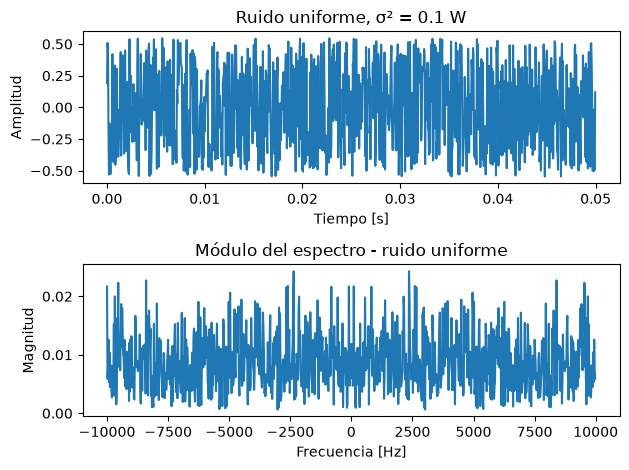

In [8]:
rango = np.sqrt(12*varianza)
#dc= 0, el intervalo debe ser simetrico respecto a dc
a = -rango/2
b = rango/2
#genero muestras aleatorias con distribucion uniforme
ruido_uniforme = np.random.uniform(a, b, N)

RU = np.fft.fft(ruido_uniforme)
RU_modulo = np.abs(RU) / N
RU_modulo = np.fft.fftshift(RU_modulo)

plt.figure()
plt.subplot(2,1,1)
plt.plot(tt, ruido_uniforme)
plt.title("Ruido uniforme, σ² = 0.1 W")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(ff_vec, RU_modulo)
plt.title("Módulo del espectro - ruido uniforme")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()

A diferencia del ruido gaussiano, que en teoría puede tomar cualquier valor, aunque los extremos sean poco probables, el ruido uniforme está limitado de forma estricta entre a y b, ninguna muestra puede superar esos valores

### Inciso 5 - Pulso rectangular

Para generar el pulso uso sig.square, con ff = 2000 Hz y duty = 0.5. Esta función devuelve valores entre +1 y -1. Como ambos valores al cuadrado dan 1, la potencia media de la señal ya es 1 W.

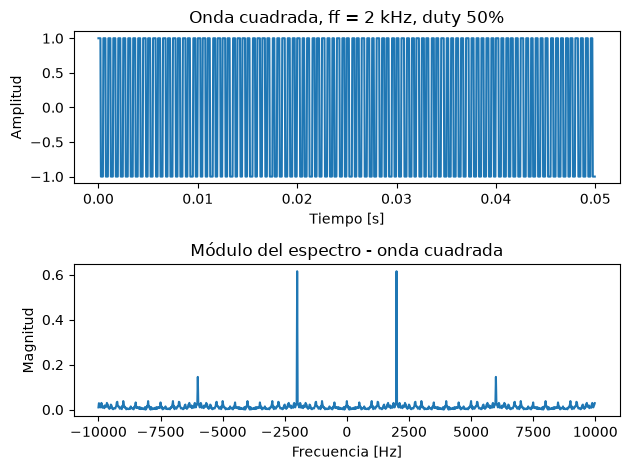

In [9]:
duty=0.5
pulso= sig.square(2*np.pi*ff*tt, duty)

P = np.fft.fft(pulso)
P_modulo = np.abs(P) / N
P_modulo = np.fft.fftshift(P_modulo)

plt.figure()

plt.subplot(2,1,1)
plt.plot(tt, pulso)
plt.title("Onda cuadrada, ff = 2 kHz, duty 50%")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(ff_vec, P_modulo)
plt.title("Módulo del espectro - onda cuadrada")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()

El espectro del pulso muestra dos picos esperados en +2000 Hz y -2000Hz, frecuencia fundamental y +6000 Hz y -6000Hz (3er armónico), correspondientes a la composición en frecuencia de un pulso cuadrado ideal. Sin embargo, también aparece un piso de ruido y pequeños picos adicionales distribuidos por todo el espectro, que no deberían estar. Esto se debe a que, con fs = 20000 Hz y duty = 0.5, las transiciones de +1 a -1 caen exactamente sobre instantes de muestreo. Ese punto de discontinuidad genera imprecisiones de punto flotante que rompen la periodicidad de la señal, produciendo fuga espectral.

### Bonus - Delta de Kronecker

Genero una delta de Kronecker con sig.unit_impulse(N), que produce una señal con un único valor igual a 1 en n=0 y cero en el resto de las muestras.

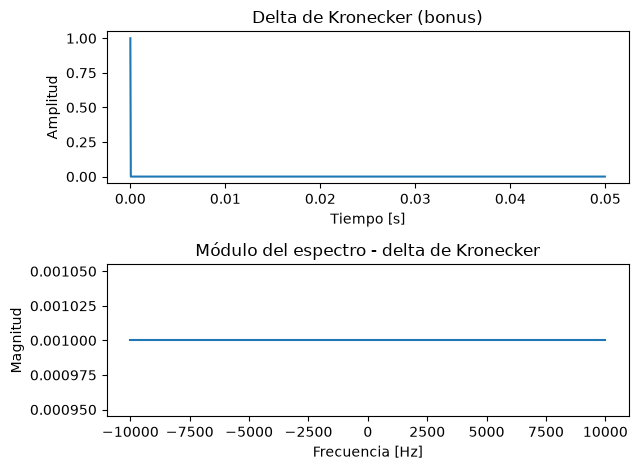

In [10]:
impulso = sig.unit_impulse(N)

I = np.fft.fft(impulso)
I_modulo = np.abs(I) / N
I_modulo = np.fft.fftshift(I_modulo)

plt.figure()
plt.subplot(2,1,1)
plt.plot(tt, impulso)
plt.title("Delta de Kronecker (bonus)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(ff_vec, I_modulo)
plt.title("Módulo del espectro - delta de Kronecker")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()

El espectro de la delta de Kronecker es una línea constante en magnitud 0.001 para todas las frecuencias cuyo valor es coherente con la normalización por N que se aplicó. Esto refleja una relación inversa entre concentración temporal y frecuencial, la delta está máximamente concentrada en el tiempo (un único valor no nulo), y por eso su energía se distribuye de manera perfectamente uniforme en todo el espectro de frecuencias. Es el caso opuesto al de una senoidal, que está muy concentrada en frecuencia pero se extiende indefinidamente en el tiempo.

## Conclusión

En este trabajo generamos distintos tipos de señales y vimos su forma tanto en el tiempo como en frecuencia usando la FFT. Notamos que las señales periódicas, como las senoidales y el pulso, tienen picos bien definidos en el espectro, en las frecuencias que las componen. En cambio, los ruidos (normal y uniforme) no tienen una frecuencia que se destaque, su energía está repartida en todo el espectro, porque no son señales periódicas. También vimos que el ruido uniforme, a diferencia del normal, está limitado entre dos valores fijos. 
Por último, con el pulso rectangular encontramos que el espectro no salía completamente limpio como esperábamos, sino que tenía ruido de fond que se debía a errores de precisión numérica en el punto exacto donde el pulso cambia de +1 a -1.